In [6]:
# from utils import *
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np


## Data Exploration

### Load dataset and inspect contents

In [7]:
data = loadmat("Data\PiecewiseSparse.mat")

A = data["A"]
Xf = data["FinalState"]

print("A shape :", A.shape)
print("Xf shape:", Xf.shape)

A shape : (25, 25)
Xf shape: (1000, 25)


<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\pablo\AppData\Local\Temp\ipykernel_12012\1995054721.py:1: SyntaxWarning: invalid escape sequence '\P'
  data = loadmat("Data\PiecewiseSparse.mat")


### Desired States

In [8]:
print("Final-state statistics")
print("----------------------")
print("Min :", Xf.min())
print("Max :", Xf.max())
print("Mean:", Xf.mean())
print("Std :", Xf.std())

Final-state statistics
----------------------
Min : -4.232539423129264
Max : 3.9976778030754976
Mean: -0.0015596130427643358
Std : 1.0029575396312087


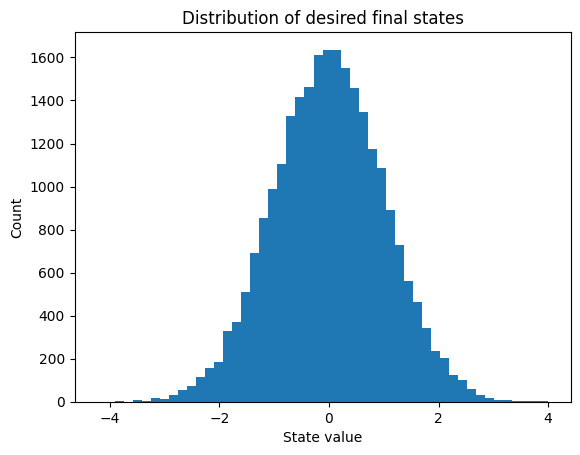

In [9]:
plt.hist(Xf.flatten(), bins=50)
plt.xlabel("State value")
plt.ylabel("Count")
plt.title("Distribution of desired final states")
plt.show()

### Network Matrix A

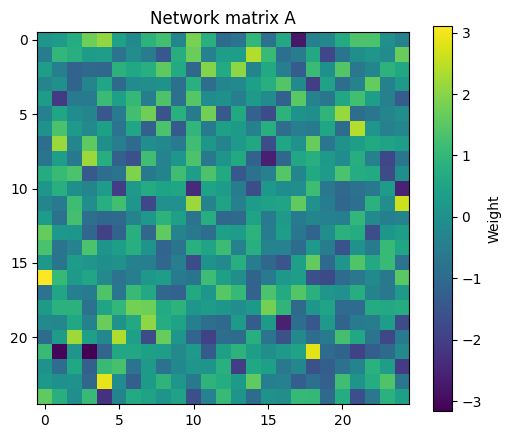

In [10]:
plt.figure(figsize=(6,5))
plt.imshow(A)
plt.colorbar(label="Weight")
plt.title("Network matrix A")
plt.show()

### Dynamics Diagnostics

In [11]:
eigvals = np.linalg.eigvals(A)

print("Spectral radius:", np.max(np.abs(eigvals)))
print("Nonzero entries:", np.count_nonzero(A))

Spectral radius: 6.077790816533421
Nonzero entries: 625


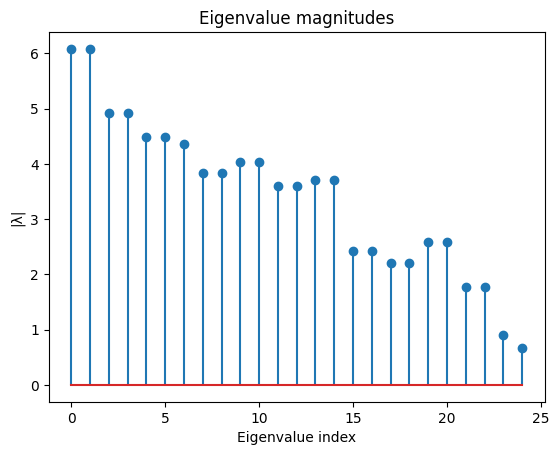

In [12]:
plt.stem(np.abs(eigvals))
plt.xlabel("Eigenvalue index")
plt.ylabel("|λ|")
plt.title("Eigenvalue magnitudes")
plt.show()

## Problem Formulation and Numerical Preprocessing

### Define horizon and target

In [13]:
N = A.shape[0]
T = N

x0 = np.zeros(N)
Y = Xf.copy()   # since x0 = 0, y = xd = Xf

print("N:", N)
print("T:", T)
print("Y shape:", Y.shape)

N: 25
T: 25
Y shape: (1000, 25)


### Build controllability matrix

In [14]:
def build_C(A, T):
    return np.hstack([np.linalg.matrix_power(A, T - 1 - k) for k in range(T)])

C = build_C(A, T)

print("C shape:", C.shape)

C shape: (25, 625)


### Check Conditioning of C

In [15]:
svals_C = np.linalg.svd(C, compute_uv=False)

print("Raw controllability matrix")
print("--------------------------")
print("Rank:", np.linalg.matrix_rank(C))
print("Largest singular value :", svals_C[0])
print("Smallest singular value:", svals_C[-1])
print("Condition number:", svals_C[0] / svals_C[-1])
print("Max absolute entry:", np.max(np.abs(C)))

Raw controllability matrix
--------------------------
Rank: 21
Largest singular value : 1.1174196847852622e+19
Smallest singular value: 154.67653068923332
Condition number: 7.224235504934578e+16
Max absolute entry: 1.9972369871924526e+18


### Column normalization / coordinate change

In [16]:
col_norms = np.linalg.norm(C, axis=0)
safe_col_norms = np.maximum(col_norms, 1e-12)

C_tilde = C / safe_col_norms[None, :]

print("Column norm range before normalization:")
print("min:", col_norms.min())
print("max:", col_norms.max())

print("\nColumn norm range after normalization:")
print("min:", np.linalg.norm(C_tilde, axis=0).min())
print("max:", np.linalg.norm(C_tilde, axis=0).max())

Column norm range before normalization:
min: 1.0
max: 4.5173382660303775e+18

Column norm range after normalization:
min: 0.9999999999999997
max: 1.0000000000000002


### Compare raw and normalised matrices

In [17]:
def matrix_diagnostics(M, name):
    svals = np.linalg.svd(M, compute_uv=False)

    print(name)
    print("-" * len(name))
    print("Rank:", np.linalg.matrix_rank(M))
    print("Largest singular value :", svals[0])
    print("Smallest singular value:", svals[-1])
    print("Condition number:", svals[0] / svals[-1])
    print()

matrix_diagnostics(C, "Raw C")
matrix_diagnostics(C_tilde, "Normalized C_tilde")

Raw C
-----
Rank: 21
Largest singular value : 1.1174196847852622e+19
Smallest singular value: 154.67653068923332
Condition number: 7.224235504934578e+16

Normalized C_tilde
------------------
Rank: 25
Largest singular value : 16.70183444149045
Smallest singular value: 1.0017891014191829
Condition number: 16.67200653094531



### Least-squares sanity check

In [18]:
def ls_sanity_check(C, C_tilde, safe_col_norms, Y, num_tests=10):
    raw_errors = []
    normalized_errors = []

    for i in range(num_tests):
        y = Y[i]

        u_raw, *_ = np.linalg.lstsq(C, y, rcond=None)
        y_hat_raw = C @ u_raw
        raw_errors.append(np.linalg.norm(y - y_hat_raw) / np.linalg.norm(y))

        z, *_ = np.linalg.lstsq(C_tilde, y, rcond=None)
        u = z / safe_col_norms
        y_hat = C @ u
        normalized_errors.append(np.linalg.norm(y - y_hat) / np.linalg.norm(y))

    print("Least-squares sanity check")
    print("--------------------------")
    print("Raw C mean error:", np.mean(raw_errors))
    print("Normalized mean error:", np.mean(normalized_errors))
    print("Raw C max error:", np.max(raw_errors))
    print("Normalized max error:", np.max(normalized_errors))

ls_sanity_check(C, C_tilde, safe_col_norms, Y)

Least-squares sanity check
--------------------------
Raw C mean error: 0.388202036642923
Normalized mean error: 2.8600722379911065e-15
Raw C max error: 0.6757882435561858
Normalized max error: 4.1138692772606135e-15


## OMP -- baseline

### OMP implementation

In [19]:
def omp(Phi, y, K):
    """
    Standard OMP with fixed global sparsity K.
    Used as a relaxed baseline with K = T*s.
    """
    m, n = Phi.shape

    residual = y.copy()
    support = []
    residual_norms = [np.linalg.norm(residual)]

    z_hat = np.zeros(n)

    for _ in range(K):
        corr = Phi.T @ residual

        if support:
            corr[support] = 0

        idx = np.argmax(np.abs(corr))
        support.append(idx)

        Phi_S = Phi[:, support]
        z_S, *_ = np.linalg.lstsq(Phi_S, y, rcond=None)

        residual = y - Phi_S @ z_S
        residual_norms.append(np.linalg.norm(residual))

    z_hat[support] = z_S

    return z_hat, support, residual_norms

### Evaluate OMP over all targets

In [20]:
def evaluate_omp(Xf, C, C_tilde, safe_col_norms, s, N=25, T=25):
    """
    OMP uses the same total budget as the piecewise problem:
        K = T*s
    but does not enforce s nonzeros per block.
    """
    K = T * s

    errors = []
    energies = []
    U_hat = []

    for y in Xf:
        z_hat, _, _ = omp(C_tilde, y, K)

        u_hat = z_hat / safe_col_norms
        x_hat = C @ u_hat

        errors.append(np.linalg.norm(y - x_hat) / np.linalg.norm(y))
        energies.append(np.linalg.norm(u_hat))
        U_hat.append(u_hat)

    return {
        "errors": np.array(errors),
        "energies": np.array(energies),
        "U_hat": np.array(U_hat),
    }

### OMP sparsity sweep

In [21]:
s_values = [1, 2, 3, 4, 5]
omp_results = {}

for s in s_values:
    res = evaluate_omp(Xf, C, C_tilde, safe_col_norms, s, N=N, T=T)
    omp_results[s] = res

    print(f"\nOMP baseline, s={s}, K={T*s}")
    print("----------------------")
    print("Mean error :", res["errors"].mean())
    print("Median error:", np.median(res["errors"]))
    print("Max error  :", res["errors"].max())
    print("Mean energy:", res["energies"].mean())


OMP baseline, s=1, K=25
----------------------
Mean error : 1.486138078183807e-15
Median error: 1.1710267698802515e-15
Max error  : 9.782999628607228e-15
Mean energy: 4.35940022845141

OMP baseline, s=2, K=50
----------------------
Mean error : 2.037227962490866e-15
Median error: 1.692580390141555e-15
Max error  : 1.068323562539239e-14
Mean energy: 3.618367834549762

OMP baseline, s=3, K=75
----------------------
Mean error : 2.0705621511200877e-15
Median error: 1.6977880068576184e-15
Max error  : 9.804120298097635e-15
Mean energy: 3.259954031051616

OMP baseline, s=4, K=100
----------------------
Mean error : 2.1277943797370275e-15
Median error: 1.7489141587424262e-15
Max error  : 1.0066733292055962e-14
Mean energy: 3.051965514425065

OMP baseline, s=5, K=125
----------------------
Mean error : 2.068810383534281e-15
Median error: 1.7060182096544466e-15
Max error  : 1.0496652860592506e-14
Mean energy: 2.925932052544993


### Block sparsity diagnostics

In [22]:
def block_sparsity_counts(U_hat, N=25, T=25, threshold=1e-10):
    """
    Returns block sparsity counts for each experiment.
    Output shape: num_experiments x T
    """
    counts = []

    for u in U_hat:
        U = u.reshape(T, N)
        block_counts = np.count_nonzero(np.abs(U) > threshold, axis=1)
        counts.append(block_counts)

    return np.array(counts)

In [23]:
for s in s_values:
    block_counts = block_sparsity_counts(omp_results[s]["U_hat"], N=N, T=T)

    print(f"\nOMP block distribution, s={s}")
    print("---------------------------")
    print("Mean total sparsity:", block_counts.sum(axis=1).mean())
    print("Mean block sparsity:", block_counts.mean())
    print("Mean max block sparsity:", block_counts.max(axis=1).mean())
    print("Mean active block fraction:", np.mean(block_counts > 0))


OMP block distribution, s=1
---------------------------
Mean total sparsity: 24.999
Mean block sparsity: 0.99996
Mean max block sparsity: 19.433
Mean active block fraction: 0.15952

OMP block distribution, s=2
---------------------------
Mean total sparsity: 49.745
Mean block sparsity: 1.9898
Mean max block sparsity: 20.458
Mean active block fraction: 0.35056

OMP block distribution, s=3
---------------------------
Mean total sparsity: 73.569
Mean block sparsity: 2.94276
Mean max block sparsity: 21.114
Mean active block fraction: 0.4116

OMP block distribution, s=4
---------------------------
Mean total sparsity: 96.775
Mean block sparsity: 3.871
Mean max block sparsity: 21.951
Mean active block fraction: 0.4468

OMP block distribution, s=5
---------------------------
Mean total sparsity: 119.561
Mean block sparsity: 4.78244
Mean max block sparsity: 22.893
Mean active block fraction: 0.4696


### OMP support heatmap

In [24]:
def support_frequency_from_U(U_hat, N=25, T=25, threshold=1e-10):
    counts = np.zeros((T, N))

    for u in U_hat:
        U = u.reshape(T, N)
        counts += (np.abs(U) > threshold)

    frequency = counts / len(U_hat)

    return counts, frequency

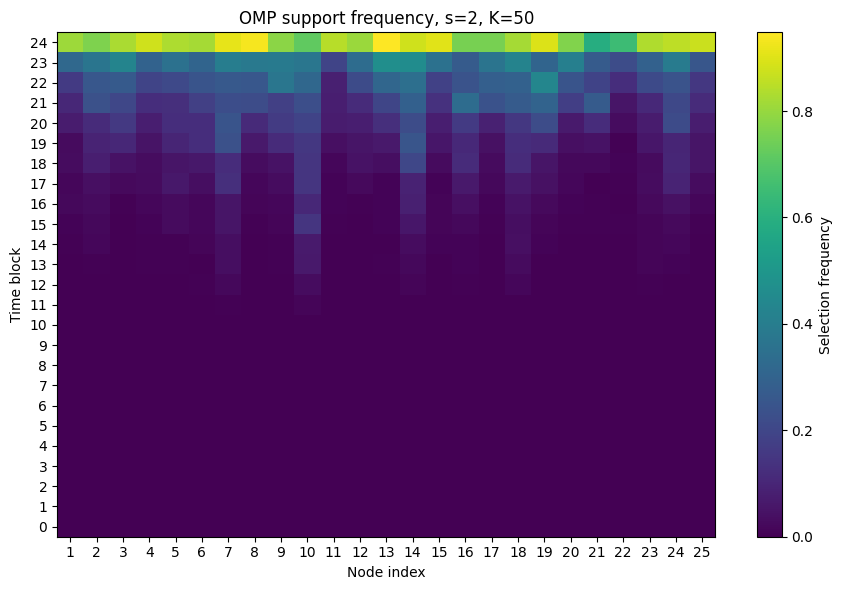

In [25]:
s = 2

_, omp_frequency = support_frequency_from_U(
    omp_results[s]["U_hat"],
    N=N,
    T=T
)

plt.figure(figsize=(9, 6))
plt.imshow(omp_frequency, aspect="auto", origin="lower")
plt.colorbar(label="Selection frequency")

plt.xlabel("Node index")
plt.ylabel("Time block")
plt.title(f"OMP support frequency, s={s}, K={T*s}")

plt.xticks(np.arange(N), np.arange(1, N+1))
plt.yticks(np.arange(T), np.arange(T))

plt.tight_layout()
plt.show()

### Average support per time block

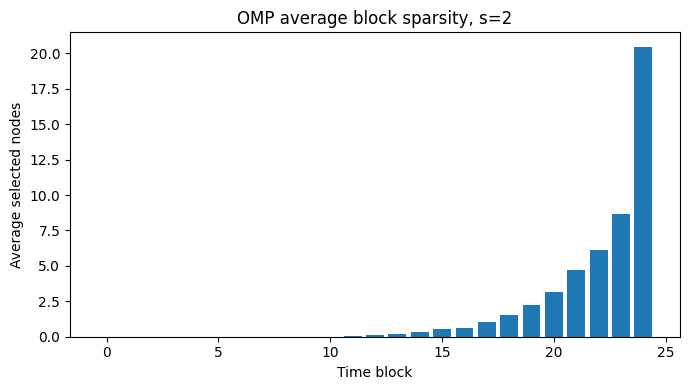

In [26]:
omp_block_usage = omp_frequency.sum(axis=1)

plt.figure(figsize=(7, 4))
plt.bar(np.arange(T), omp_block_usage)

plt.xlabel("Time block")
plt.ylabel("Average selected nodes")
plt.title(f"OMP average block sparsity, s={s}")

plt.tight_layout()
plt.show()

## POMP method

### Helper Functions

In [27]:
def top_k_abs_indices(v, k):
    """Indices of the k largest absolute entries."""
    k = min(k, len(v))
    if k <= 0:
        return np.array([], dtype=int)
    return np.argpartition(np.abs(v), -k)[-k:]


def piecewise_prune(z, s, N=25, T=25):
    """Keep at most s entries inside each time block."""
    z_pruned = np.zeros_like(z)

    for t in range(T):
        start, end = t*N, (t+1)*N
        local_idx = top_k_abs_indices(z[start:end], s)
        z_pruned[start + local_idx] = z[start + local_idx]

    return z_pruned

### POMP implementation

In [28]:
def pomp(Phi, y, s, N=25, T=25, max_iter=None, tol=1e-12):
    """
    Piecewise OMP.

    Enforces:
        ||u_t||_0 <= s  for every time block t.

    The best iterate is returned, since pruning can occasionally increase
    the residual after later iterations.
    """
    if max_iter is None:
        max_iter = s

    n = N * T
    z = np.zeros(n)
    support = np.array([], dtype=int)

    residual = y.copy()
    residual_norms = [np.linalg.norm(residual)]

    best_z = z.copy()
    best_residual_norm = residual_norms[0]

    for _ in range(max_iter):
        proxy = Phi.T @ residual

        new_support = []
        for t in range(T):
            start, end = t*N, (t+1)*N
            local_idx = top_k_abs_indices(proxy[start:end], s)
            new_support.extend(start + local_idx)

        merged_support = np.union1d(support, np.array(new_support))

        Phi_S = Phi[:, merged_support]
        z_S, *_ = np.linalg.lstsq(Phi_S, y, rcond=None)

        z_temp = np.zeros(n)
        z_temp[merged_support] = z_S

        z = piecewise_prune(z_temp, s=s, N=N, T=T)
        support = np.flatnonzero(np.abs(z) > 1e-12)

        residual = y - Phi @ z
        res_norm = np.linalg.norm(residual)
        residual_norms.append(res_norm)

        if res_norm < best_residual_norm:
            best_residual_norm = res_norm
            best_z = z.copy()

        if res_norm <= tol:
            break

    best_support = np.flatnonzero(np.abs(best_z) > 1e-12)

    return best_z, best_support, residual_norms

### Evaluate POMP over all targets

In [29]:
def evaluate_pomp(Xf, C, C_tilde, safe_col_norms, s, N=25, T=25):
    errors = []
    energies = []
    U_hat = []

    for y in Xf:
        z_hat, _, _ = pomp(
            Phi=C_tilde,
            y=y,
            s=s,
            N=N,
            T=T,
            max_iter=s
        )

        u_hat = z_hat / safe_col_norms
        x_hat = C @ u_hat

        errors.append(np.linalg.norm(y - x_hat) / np.linalg.norm(y))
        energies.append(np.linalg.norm(u_hat))
        U_hat.append(u_hat)

    return {
        "errors": np.array(errors),
        "energies": np.array(energies),
        "U_hat": np.array(U_hat),
    }

### POMP sparsity sweep

In [30]:
s_values = [1, 2, 3, 4, 5]
pomp_results = {}

for s in s_values:
    res = evaluate_pomp(Xf, C, C_tilde, safe_col_norms, s, N=N, T=T)
    pomp_results[s] = res

    print(f"\nPOMP, s={s}")
    print("-----------")
    print("Mean error :", res["errors"].mean())
    print("Median error:", np.median(res["errors"]))
    print("Max error  :", res["errors"].max())
    print("Mean energy:", res["energies"].mean())


POMP, s=1
-----------
Mean error : 2.4628864025995962e-08
Median error: 1.7170794174771346e-09
Max error  : 9.197695491826367e-06
Mean energy: 57.04456446991997

POMP, s=2
-----------
Mean error : 1.059072729758187e-13
Median error: 6.518435711852386e-14
Max error  : 2.114109978434753e-12
Mean energy: 10.194752424016635

POMP, s=3
-----------
Mean error : 9.057122381903384e-15
Median error: 7.370970799759705e-15
Max error  : 8.245822504271079e-14
Mean energy: 7.9626024574130705

POMP, s=4
-----------
Mean error : 4.093173575424234e-15
Median error: 3.583060058890161e-15
Max error  : 1.648214751196236e-14
Mean energy: 6.578074849622617

POMP, s=5
-----------
Mean error : 3.3238350136606476e-15
Median error: 2.8516719364459336e-15
Max error  : 1.0080615645860166e-14
Mean energy: 5.768571171005436


### Verify piecewise constraint

In [31]:
for s in s_values:
    block_counts = block_sparsity_counts(pomp_results[s]["U_hat"], N=N, T=T)

    print(f"\nPOMP block distribution, s={s}")
    print("----------------------------")
    print("Mean total sparsity:", block_counts.sum(axis=1).mean())
    print("Mean block sparsity:", block_counts.mean())
    print("Mean max block sparsity:", block_counts.max(axis=1).mean())
    print("Largest observed block sparsity:", block_counts.max())


POMP block distribution, s=1
----------------------------
Mean total sparsity: 22.318
Mean block sparsity: 0.89272
Mean max block sparsity: 1.0
Largest observed block sparsity: 1

POMP block distribution, s=2
----------------------------
Mean total sparsity: 32.887
Mean block sparsity: 1.31548
Mean max block sparsity: 2.0
Largest observed block sparsity: 2

POMP block distribution, s=3
----------------------------
Mean total sparsity: 43.686
Mean block sparsity: 1.74744
Mean max block sparsity: 3.0
Largest observed block sparsity: 3

POMP block distribution, s=4
----------------------------
Mean total sparsity: 54.605
Mean block sparsity: 2.1842
Mean max block sparsity: 4.0
Largest observed block sparsity: 4

POMP block distribution, s=5
----------------------------
Mean total sparsity: 65.34
Mean block sparsity: 2.6136
Mean max block sparsity: 5.0
Largest observed block sparsity: 5


### POMP support heatmap

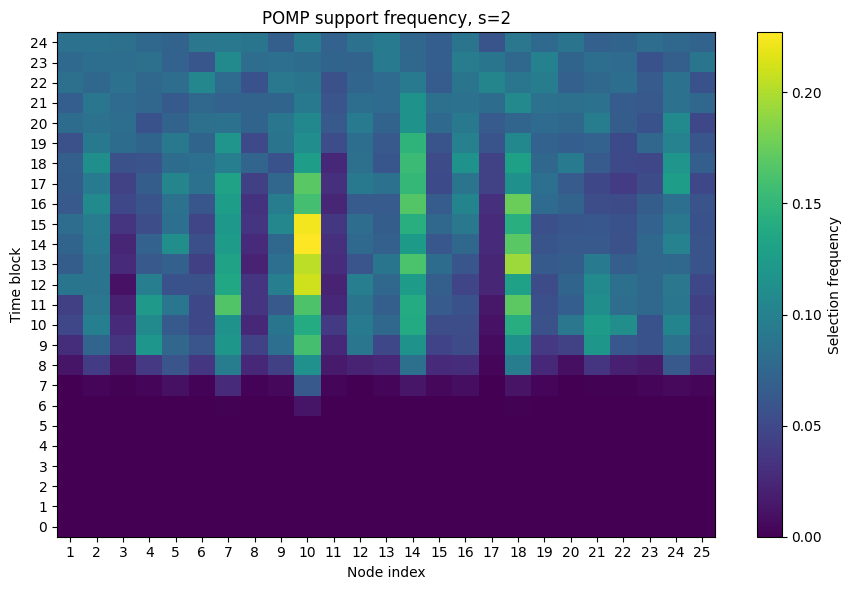

In [32]:
s = 2

_, pomp_frequency = support_frequency_from_U(
    pomp_results[s]["U_hat"],
    N=N,
    T=T
)

plt.figure(figsize=(9, 6))
plt.imshow(pomp_frequency, aspect="auto", origin="lower")
plt.colorbar(label="Selection frequency")

plt.xlabel("Node index")
plt.ylabel("Time block")
plt.title(f"POMP support frequency, s={s}")

plt.xticks(np.arange(N), np.arange(1, N+1))
plt.yticks(np.arange(T), np.arange(T))

plt.tight_layout()
plt.show()

## SBL / block SBL

In [41]:
def pcsbl_piecewise(Phi, y, N=25, T=25,
                    beta_couple=1.0,
                    a=0.5, b=1e-4,
                    noise_var=1e-6,
                    max_iter=300,
                    tol=1e-6,
                    alpha_max=1e12,
                    prune_thresh=1e-4,
                    per_block_cap=None):
    """
    Pattern-Coupled SBL (Fang, Shen, Li, Wang, IEEE TSP 2014),
    adapted to PIECEWISE structure: hyperparameter coupling is cut at
    block boundaries so clustering pressure stays within each time block
    (matches U2 piecewise, not U3 block sparsity).

    Prior:  z_j ~ N(0, (alpha_j + beta*alpha_{j-1} + beta*alpha_{j+1})^-1)
            with neighbors restricted to the same length-N block.

    beta_couple = 0  -> reduces to plain SBL.
    beta_couple > 0  -> couples neighbors within each block.

    E-step uses Woodbury (work in m x m measurement space, since m << n).

    Returns
    -------
    z_hat   : (n,) recovered coefficients (normalized-column space)
    support : indices of nonzeros after pruning
    info    : dict (alpha, n_iter, converged, z_dense)
    """
    m, n = Phi.shape
    beta_noise = 1.0 / noise_var          # measurement precision

    # --- Precompute within-block neighbor index lists ---
    # left[j]  = index of left neighbor (or -1 if none / across boundary)
    # right[j] = index of right neighbor (or -1)
    left = np.full(n, -1, dtype=int)
    right = np.full(n, -1, dtype=int)
    for t in range(T):
        start, end = t * N, (t + 1) * N
        idx = np.arange(start, end)
        left[idx[1:]] = idx[:-1]     # each has a left neighbor except block-first
        right[idx[:-1]] = idx[1:]    # each has a right neighbor except block-last

    alpha = np.ones(n)               # hyper-precisions
    z_hat = np.zeros(n)
    delta = np.inf

    for it in range(max_iter):
        alpha_prev = alpha.copy()

        # --- Effective per-coefficient precision (pattern-coupled) ---
        eff_prec = alpha.copy()
        has_left = left >= 0
        has_right = right >= 0
        eff_prec[has_left]  += beta_couple * alpha[left[has_left]]
        eff_prec[has_right] += beta_couple * alpha[right[has_right]]

        gamma = 1.0 / eff_prec        # effective prior variances (diag of prior cov)

        # --- E-step via Woodbury (m x m solve) ---
        PhiG = Phi * gamma[None, :]                 # Phi @ diag(gamma)
        B = (1.0 / beta_noise) * np.eye(m) + PhiG @ Phi.T
        Binv = np.linalg.inv(B)

        mu = gamma * (Phi.T @ (Binv @ y))           # posterior mean
        BinvPhi = Binv @ Phi
        diag_quad = np.sum(Phi * BinvPhi, axis=0)   # phi_j^T B^-1 phi_j
        Sigma_diag = gamma - (gamma**2) * diag_quad # posterior variances

        z_hat = mu
        energy = mu**2 + Sigma_diag                 # per-coefficient "energy"

        # --- M-step: pattern-coupled update for alpha ---
        # Each coefficient's energy is attributed to itself and (with weight
        # beta) to its within-block neighbors. omega_j aggregates these.
        omega = energy.copy()
        omega[has_left]  += beta_couple * energy[left[has_left]]
        omega[has_right] += beta_couple * energy[right[has_right]]

        alpha = (2.0 * a + 1.0) / (2.0 * b + omega)
        alpha = np.minimum(alpha, alpha_max)

        delta = np.linalg.norm(alpha - alpha_prev) / (np.linalg.norm(alpha_prev) + 1e-300)
        if delta < tol:
            break

    # --- Natural pruning relative to largest coefficient ---
    z_pruned = z_hat.copy()
    peak = np.max(np.abs(z_pruned))
    if peak > 0:
        z_pruned[np.abs(z_pruned) < prune_thresh * peak] = 0.0

    # --- Optional per-block cap (ablation only) ---
    if per_block_cap is not None:
        capped = np.zeros_like(z_pruned)
        for t in range(T):
            s0, s1 = t * N, (t + 1) * N
            blk = z_pruned[s0:s1]
            k = min(per_block_cap, np.count_nonzero(blk))
            if k > 0:
                loc = top_k_abs_indices(blk, k)
                capped[s0 + loc] = blk[loc]
        z_pruned = capped

    support = np.flatnonzero(z_pruned)
    info = {
        "alpha": alpha,
        "n_iter": it + 1,
        "converged": delta < tol,
        "z_dense": z_hat,
    }
    return z_pruned, support, info

In [42]:
def evaluate_pcsbl(Xf, C, C_tilde, safe_col_norms, N=25, T=25,
                   beta_couple=1.0, a=0.5, b=1e-4, noise_var=1e-6,
                   prune_thresh=1e-4, per_block_cap=None):
    errors, energies, U_hat, n_iters = [], [], [], []

    for y in Xf:
        z_hat, _, info = pcsbl_piecewise(
            Phi=C_tilde, y=y, N=N, T=T,
            beta_couple=beta_couple, a=a, b=b,
            noise_var=noise_var, prune_thresh=prune_thresh,
            per_block_cap=per_block_cap,
        )
        u_hat = z_hat / safe_col_norms
        x_hat = C @ u_hat

        errors.append(np.linalg.norm(y - x_hat) / np.linalg.norm(y))
        energies.append(np.linalg.norm(u_hat))
        U_hat.append(u_hat)
        n_iters.append(info["n_iter"])

    return {
        "errors": np.array(errors),
        "energies": np.array(energies),
        "U_hat": np.array(U_hat),
        "n_iters": np.array(n_iters),
    }

In [43]:
# Quick run on a subset first.
n_test = 100

pcsbl_res = evaluate_pcsbl(
    Xf[:n_test], C, C_tilde, safe_col_norms,
    N=N, T=T, beta_couple=1.0, noise_var=1e-6, prune_thresh=1e-4
)

print("PC-SBL (piecewise, block-boundary-aware coupling)")
print("-------------------------------------------------")
print("Mean error :", pcsbl_res["errors"].mean())
print("Median error:", np.median(pcsbl_res["errors"]))
print("Max error  :", pcsbl_res["errors"].max())
print("Mean energy:", pcsbl_res["energies"].mean())
print("Mean iters :", pcsbl_res["n_iters"].mean())

block_counts = block_sparsity_counts(pcsbl_res["U_hat"], N=N, T=T, threshold=1e-10)
print("\nRealized sparsity")
print("Mean total sparsity    :", block_counts.sum(axis=1).mean())
print("Mean block sparsity    :", block_counts.mean())
print("Mean max block sparsity:", block_counts.max(axis=1).mean())

PC-SBL (piecewise, block-boundary-aware coupling)
-------------------------------------------------
Mean error : 0.004815967214986353
Median error: 0.0049536274034808455
Max error  : 0.01196058142884743
Mean energy: 4.549810200322515
Mean iters : 49.19

Realized sparsity
Mean total sparsity    : 93.35
Mean block sparsity    : 3.734
Mean max block sparsity: 24.83


In [44]:
beta_values = [0.0, 0.25, 0.5, 0.75, 1.0]
beta_sweep = {}

for bc in beta_values:
    res = evaluate_pcsbl(
        Xf[:n_test], C, C_tilde, safe_col_norms,
        N=N, T=T, beta_couple=bc, noise_var=1e-6, prune_thresh=1e-4
    )
    bcnts = block_sparsity_counts(res["U_hat"], N=N, T=T, threshold=1e-10)
    beta_sweep[bc] = res

    print(f"\nbeta={bc}")
    print("  mean error :", res["errors"].mean())
    print("  mean energy:", res["energies"].mean())
    print("  mean block sparsity:", bcnts.mean())
    print("  mean total sparsity:", bcnts.sum(axis=1).mean())


beta=0.0
  mean error : 0.0006076157939540652
  mean energy: 3.6336188740100677
  mean block sparsity: 8.918
  mean total sparsity: 222.95

beta=0.25
  mean error : 0.0024909190954814043
  mean energy: 4.3739689595148254
  mean block sparsity: 6.466
  mean total sparsity: 161.65

beta=0.5
  mean error : 0.003584790638565446
  mean energy: 4.47563004964406
  mean block sparsity: 5.36
  mean total sparsity: 134.0

beta=0.75
  mean error : 0.004459091257969706
  mean energy: 4.515512149945616
  mean block sparsity: 4.4012
  mean total sparsity: 110.03

beta=1.0
  mean error : 0.004815967214986353
  mean energy: 4.549810200322515
  mean block sparsity: 3.734
  mean total sparsity: 93.35
